In [ ]:
# Step 1: Import Libraries & Check GPU

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn (for evaluation + later ML models)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Image handling
from PIL import Image
import cv2

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is enabled — training will be faster!")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → Select T4 GPU")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is enabled — training will be faster!


In [ ]:
# ==========================================
# STEP 2: DOWNLOAD & EXPLORE DATASETS
# ==========================================
import os
import zipfile
import kagglehub
from google.colab import drive

# ─── 1. MOUNT GOOGLE DRIVE & EXTRACT YOLO ───
print("🔄 Mounting Google Drive...")
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/FYP_Datasets/yollo.zip'
yolo_path = '/content/yolo_dataset'
os.makedirs(yolo_path, exist_ok=True)

print("\n📦 Extracting YOLO dataset from Drive...")
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(yolo_path)
    print(f"✅ YOLO dataset ready at: {yolo_path}")
else:
    print(f"❌ Error: YOLO zip not found at {zip_path}")

# ─── 2. DOWNLOAD AXIAL CT DATASET ───
print("\n📥 Downloading Axial CT Classification dataset...")
cnn_raw_path = kagglehub.dataset_download("orvile/axial-ct-imaging-dataset-kidney-stone-detection")
print(f"✅ CNN raw dataset saved to: {cnn_raw_path}")

# ─── 3. EXPLORE FOLDER STRUCTURE ───
def explore_folder(root_path, name, max_depth=3):
    print(f"\n{'='*60}")
    print(f"📁 {name} Structure")
    print(f"   Path: {root_path}")
    print(f"{'='*60}")

    if not os.path.exists(root_path):
        print("⚠️ Path does not exist!")
        return

    for dirpath, dirnames, filenames in os.walk(root_path):
        level = dirpath.replace(root_path, '').count(os.sep)
        if level > max_depth:
            continue

        indent = '  ' * level
        folder_name = os.path.basename(dirpath)

        # Only count image files
        img_count = sum(1 for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png')))

        # Only print folders that contain images or subfolders
        if img_count > 0 or dirnames:
            print(f"{indent}📂 {folder_name}/ ({img_count} images)")

# We use max_depth=4 to clearly see inside Original and Augmented folders
explore_folder(cnn_raw_path, "Axial CT Dataset", max_depth=4)
explore_folder(yolo_path, "YOLO Detection Dataset", max_depth=2)

print("\n✅ Step 2 Complete: Datasets downloaded and explored!")


🔄 Mounting Google Drive...
Mounted at /content/drive

📦 Extracting YOLO dataset from Drive...
✅ YOLO dataset ready at: /content/yolo_dataset

📥 Downloading Axial CT Classification dataset...


100%|██████████| 3.78G/3.78G [00:45<00:00, 88.6MB/s]

Extracting files...


✅ CNN raw dataset saved to: /root/.cache/kagglehub/datasets/orvile/axial-ct-imaging-dataset-kidney-stone-detection/versions/2

📁 Axial CT Dataset Structure
   Path: /root/.cache/kagglehub/datasets/orvile/axial-ct-imaging-dataset-kidney-stone-detection/versions/2
📂 2/ (0 images)
  📂 Axial CT Imaging Dataset for AI-Powered Kidney Stone Detection A Resource for Deep Learning Research/ (0 images)
    📂 Axial CT Imaging Dataset for AI-Powered Kidney Stone Detection A Resource for Deep Learning Research/ (0 images)
      📂 Kindy Stone Dataset/ (0 images)
        📂 Augmented Dataset/ (0 images)
        📂 Original Dataset/ (0 images)

📁 YOLO Detection Dataset Structure
   Path: /content/yolo_dataset
📂 yolo_dataset/ (0 images)
  📂 train/ (0 images)
    📂 images/ (1054 images)
  📂 valid/ (0 images)
    📂 images/ (123 images)
  📂 test/ (0 images)
    📂 images/ (123 images)

✅ Step 2 Complete: Datasets downloaded and explored!


In [ ]:
# ==========================================
# STEP 3: DATA RESTRUCTURING & SPLITTING
# ==========================================
import os
import shutil
from sklearn.model_selection import train_test_split

print("🧹 Starting Data Clean-up and Restructuring...")

# ─── 1. DEFINE CLEAN DIRECTORY STRUCTURE ───
clean_dataset_dir = '/content/cnn_dataset_clean'
train_dir = os.path.join(clean_dataset_dir, 'train')
valid_dir = os.path.join(clean_dataset_dir, 'valid')

# Create clean train/valid folders with strict 'Normal' and 'Stone' subfolders
for split in [train_dir, valid_dir]:
    os.makedirs(os.path.join(split, 'Normal'), exist_ok=True)
    os.makedirs(os.path.join(split, 'Stone'), exist_ok=True)

# ─── 2. GATHER AND STANDARDIZE IMAGES ───
normal_imgs = []
stone_imgs = []

# Fallback just in case runtime disconnected
if 'cnn_raw_path' not in locals():
    base = "/root/.cache/kagglehub/datasets/orvile/axial-ct-imaging-dataset-kidney-stone-detection"
    cnn_raw_path = os.path.join(base, os.listdir(base)[0]) if os.path.exists(base) else None

# Walk through the messy dataset
for dirpath, _, filenames in os.walk(cnn_raw_path):
    folder_name = os.path.basename(dirpath).lower()

    # Logic to determine actual class based on folder name
    label = None
    if 'non-stone' in folder_name or 'normal' in folder_name:
        label = 'Normal'
    elif 'stone' in folder_name and 'non' not in folder_name:
        label = 'Stone'

    if label:
        for f in filenames:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(dirpath, f)
                if label == 'Normal':
                    normal_imgs.append(full_path)
                else:
                    stone_imgs.append(full_path)

# Remove any accidental duplicates
normal_imgs = list(set(normal_imgs))
stone_imgs = list(set(stone_imgs))

print(f"📊 Found {len(normal_imgs)} 'Normal' images and {len(stone_imgs)} 'Stone' images.")

# ─── 3. SPLIT DATA (80% Train, 20% Valid) ───
train_normal, valid_normal = train_test_split(normal_imgs, test_size=0.2, random_state=42)
train_stone, valid_stone = train_test_split(stone_imgs, test_size=0.2, random_state=42)

# ─── 4. COPY FILES TO CLEAN STRUCTURE ───
def copy_files(file_list, dest_folder, prefix):
    for idx, f in enumerate(file_list):
        ext = os.path.splitext(f)[1]
        new_name = f"{prefix}_{idx:05d}{ext}" # Renames files neatly
        shutil.copy(f, os.path.join(dest_folder, new_name))

print("\n⏳ Copying files to clean train/valid folders... (This might take a minute)")

copy_files(train_normal, os.path.join(train_dir, 'Normal'), "norm")
copy_files(valid_normal, os.path.join(valid_dir, 'Normal'), "norm")

copy_files(train_stone, os.path.join(train_dir, 'Stone'), "stone")
copy_files(valid_stone, os.path.join(valid_dir, 'Stone'), "stone")

# ─── 5. FINAL SUMMARY ───
print("\n✅ Step 3 Complete: Data Restructuring Successful!")
print("="*40)
print(f"📁 Clean Dataset Path: {clean_dataset_dir}")
print(f"   📈 Train Normal: {len(train_normal)}")
print(f"   📉 Train Stone : {len(train_stone)}")
print(f"   📈 Valid Normal: {len(valid_normal)}")
print(f"   📉 Valid Stone : {len(valid_stone)}")
print("="*40)


🧹 Starting Data Clean-up and Restructuring...
📊 Found 20627 'Normal' images and 18194 'Stone' images.

⏳ Copying files to clean train/valid folders... (This might take a minute)

✅ Step 3 Complete: Data Restructuring Successful!
📁 Clean Dataset Path: /content/cnn_dataset_clean
   📈 Train Normal: 16501
   📉 Train Stone : 14555
   📈 Valid Normal: 4126
   📉 Valid Stone : 3639


In [ ]:
# ==========================================
# STEP 4 (UPDATED): DATA GENERATORS + TRANSFER LEARNING MODEL
# ==========================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

print("⚙️ Preparing Data Generators and Building Transfer Learning Model...")

# ─── 1. CONFIGURATION ───
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

clean_dataset_dir = '/content/cnn_dataset_clean'
train_dir = f'{clean_dataset_dir}/train'
valid_dir = f'{clean_dataset_dir}/valid'

# ─── 2. DATA GENERATORS ───
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05
)

valid_datagen = ImageDataGenerator(rescale=1.0/255.0)

print("\n📊 Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\n📊 Loading Validation Data:")
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ─── 3. LOAD PRETRAINED MODEL ───
print("\n🧠 Loading MobileNetV2 (Transfer Learning)...")

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# ─── 4. CUSTOM CLASSIFICATION HEAD ───
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# ─── 5. COMPILE MODEL ───
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # LOWER LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Step 4 Complete: Transfer Learning Model Ready!")
print("="*60)
model.summary()

print(f"\n🏷️ Class Indices: {train_generator.class_indices}")

⚙️ Preparing Data Generators and Building Transfer Learning Model...

📊 Loading Training Data:
Found 31056 images belonging to 2 classes.

📊 Loading Validation Data:
Found 7765 images belonging to 2 classes.

🧠 Loading MobileNetV2 (Transfer Learning)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✅ Step 4 Complete: Transfer Learning Model Ready!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


🏷️ Class Indices: {'Normal': 0, 'Stone': 1}


🚀 Preparing Callbacks and Starting Training...

⚖️ Class Weights: {0: np.float64(0.9410338767347434), 1: np.float64(1.0668498797664032)}

⏳ Training for up to 12 Epochs...
⚡ Make sure GPU is ON (Runtime → Change runtime → GPU)

Epoch 1/12
971/971 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.6180 - loss: 0.6605
Epoch 1: val_loss improved from None to 0.51776, saving model to /content/fyp_kidney_stone_binary_model.keras

Epoch 1: finished saving model to /content/fyp_kidney_stone_binary_model.keras
971/971 ━━━━━━━━━━━━━━━━━━━━ 554s 547ms/step - accuracy: 0.6734 - loss: 0.6019 - val_accuracy: 0.7542 - val_loss: 0.5178 - learning_rate: 1.0000e-04
Epoch 2/12
971/971 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.7382 - loss: 0.5243
Epoch 2: val_loss improved from 0.51776 to 0.46405, saving model to /content/fyp_kidney_stone_binary_model.keras

Epoch 2: finished saving model to /content/fyp_kidney_stone_binary_model.keras
971/971 ━━━━━━━━━━━━━━━━━━━━ 477s 492ms/step - accuracy: 0.7509 

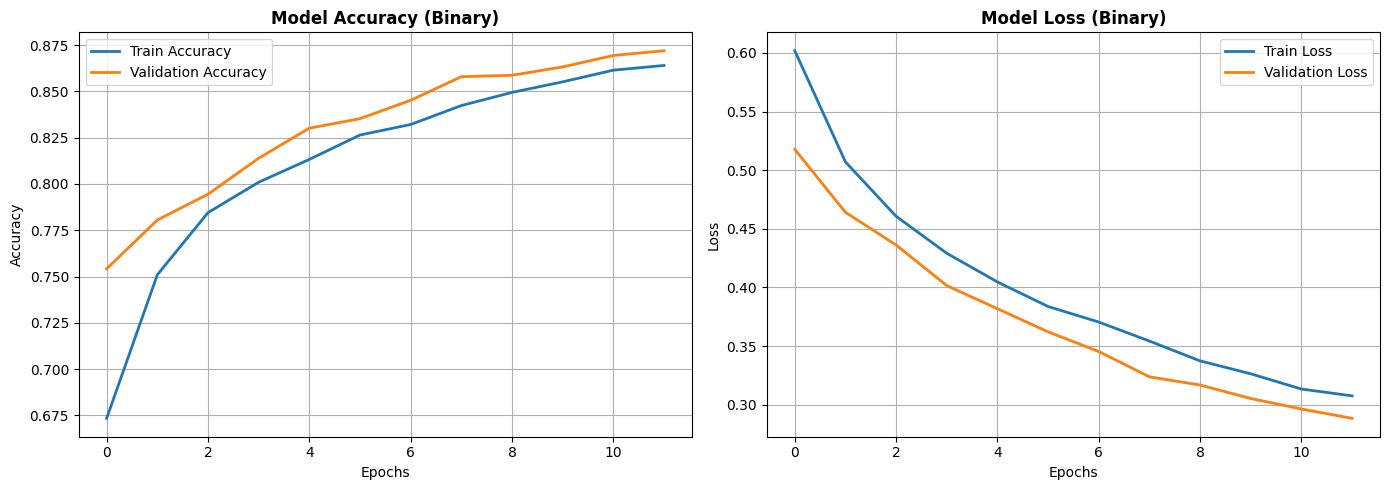

In [ ]:
# ==========================================
# STEP 5: TRAIN TRANSFER LEARNING MODEL (FINAL)
# ==========================================
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("🚀 Preparing Callbacks and Starting Training...\n")

# ─── 1. OPTIONAL: HANDLE CLASS IMBALANCE ───
# (Very important if dataset is uneven)

classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(f"⚖️ Class Weights: {class_weights}\n")

# ─── 2. DEFINE CALLBACKS ───

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ✅ Save in NEW format (fix warning)
model_save_path = '/content/fyp_kidney_stone_binary_model.keras'

checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [early_stopping, checkpoint, reduce_lr]

# ─── 3. START TRAINING ───
EPOCHS = 12

print(f"⏳ Training for up to {EPOCHS} Epochs...")
print("⚡ Make sure GPU is ON (Runtime → Change runtime → GPU)\n")

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weights   # 🔥 improves performance
)

print("\n✅ Training Complete!")
print(f"💾 Best model saved at: {model_save_path}")

# ─── 4. PLOT TRAINING HISTORY ───
print("\n📈 Generating Training Plots...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy (Binary)', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss (Binary)', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

🔄 Loading the best saved binary model...

🧠 Generating predictions on the validation set...
243/243 ━━━━━━━━━━━━━━━━━━━━ 37s 130ms/step

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.86      0.90      0.88      4126
       Stone       0.88      0.84      0.86      3639

    accuracy                           0.87      7765
   macro avg       0.87      0.87      0.87      7765
weighted avg       0.87      0.87      0.87      7765


📊 CONFUSION MATRIX ANALYSIS
Raw Confusion Matrix:
[3713 413 ] <- Actual Normal
[581  3058] <- Actual Stone


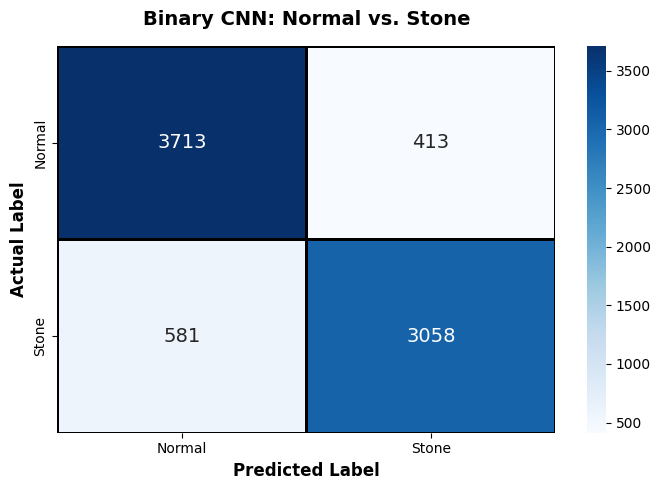


✅ Step 6 Complete: Evaluation ready for FYP Report!


In [ ]:
# ==========================================
# STEP 6: EVALUATE BINARY CNN MODEL (FINAL)
# ==========================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

print("🔄 Loading the best saved binary model...")

# ✅ FIXED PATH (.keras instead of .h5)
best_binary_model = load_model('/content/fyp_kidney_stone_binary_model.keras')

# ─── 1. PREPARE PREDICTIONS ───
valid_generator.reset()

print("\n🧠 Generating predictions on the validation set...")
predictions = best_binary_model.predict(valid_generator, verbose=1)

predicted_classes = (predictions >= 0.5).astype(int).flatten()

true_classes = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())

# ─── 2. CLASSIFICATION REPORT ───
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)

report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# ─── 3. CONFUSION MATRIX ───
print("\n" + "="*60)
print("📊 CONFUSION MATRIX ANALYSIS")
print("="*60)

cm = confusion_matrix(true_classes, predicted_classes)

print("Raw Confusion Matrix:")
print(f"[{cm[0][0]:<4} {cm[0][1]:<4}] <- Actual {class_labels[0]}")
print(f"[{cm[1][0]:<4} {cm[1][1]:<4}] <- Actual {class_labels[1]}")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            linewidths=1, linecolor='black',
            annot_kws={"size": 14})

plt.title('Binary CNN: Normal vs. Stone', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Step 6 Complete: Evaluation ready for FYP Report!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⚙️ Setting up YOLOv8 Environment...
✅ dataset.yaml created successfully (Validation folder set to: 'valid').

📊 DATASET VERIFICATION:
   Train Images Found : 1054
   Train Labels Found : 1054

📂 Checking one label file content to ensure YOLO format (0 to 1 range):
----------------------------------------
0 0.27621483375959077 0.821875 0.028132992327365727 0.01875
0 0.7723785166240409 0.759375 0.020460358056265986 0.028125
----------------------------------------
✅ Coordinates look normalized and correct!

🖼️ Displaying 4 Sample Images to Verify Annotations...


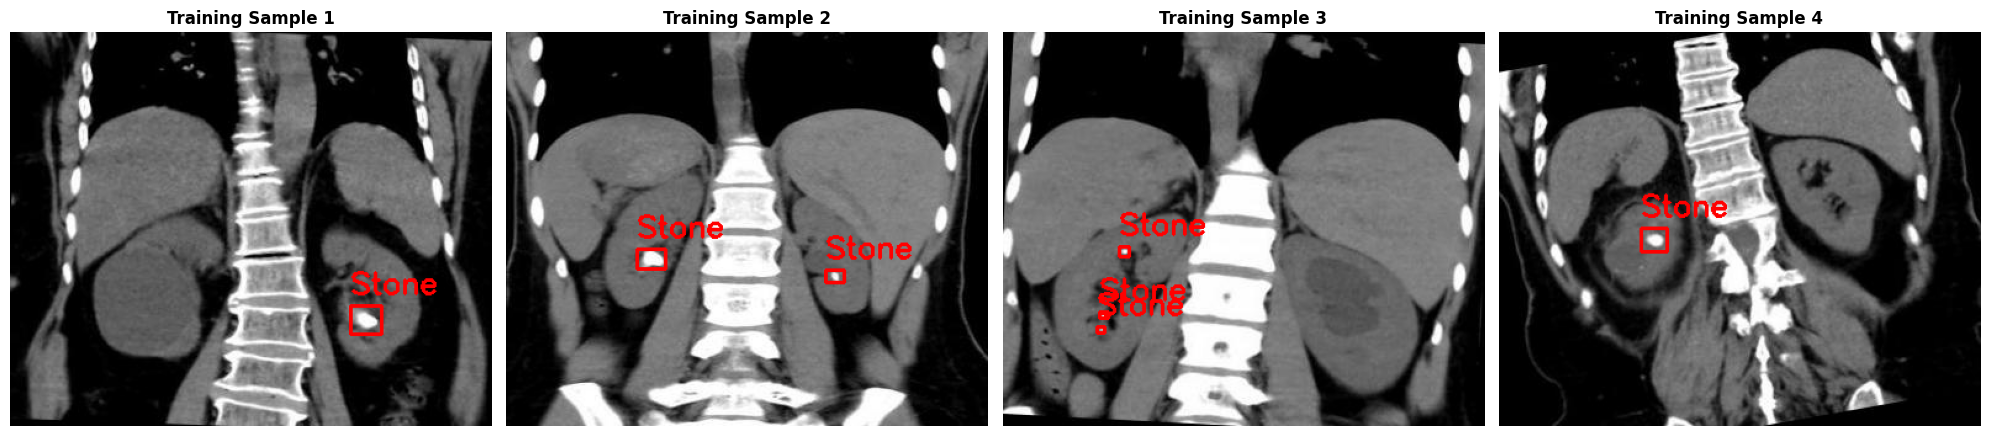

In [ ]:
# ==========================================
# STEP 7A: YOLOv8 SETUP & DATASET VERIFICATION
# ==========================================
!pip install -q ultralytics
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("⚙️ Setting up YOLOv8 Environment...")

# ─── 1. PATHS AND YAML CREATION ───
yolo_root = '/content/yolo_dataset'
train_img_dir = os.path.join(yolo_root, 'train', 'images')

# Check if the validation folder is named 'val' or 'valid' and adjust dynamically!
val_folder_name = 'valid' if os.path.exists(os.path.join(yolo_root, 'valid')) else 'val'

yaml_content = f"""
path: {yolo_root}
train: train/images
val: {val_folder_name}/images

nc: 1
names: ['Stone']
"""
yaml_path = '/content/dataset.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ dataset.yaml created successfully (Validation folder set to: '{val_folder_name}').")

# ─── 2. VERIFY DATASET ───
train_images = glob.glob(f"{train_img_dir}/*.jpg") + glob.glob(f"{train_img_dir}/*.png")
train_labels = glob.glob(os.path.join(yolo_root, 'train', 'labels', '*.txt'))

print(f"\n📊 DATASET VERIFICATION:")
print(f"   Train Images Found : {len(train_images)}")
print(f"   Train Labels Found : {len(train_labels)}")

# ─── NEW: DEBUG LABEL FILE CONTENT ───
print("\n📂 Checking one label file content to ensure YOLO format (0 to 1 range):")
if train_labels:
    with open(train_labels[0], 'r') as f:
        content = f.read()
        print("-" * 40)
        print(content.strip())
        print("-" * 40)

        # Quick safety check
        try:
            parts = content.strip().split()
            if float(parts[1]) > 1.0 or float(parts[2]) > 1.0:
                print("❌ WARNING: Coordinates are > 1.0. They must be normalized (0 to 1) for YOLO!")
            else:
                print("✅ Coordinates look normalized and correct!")
        except Exception:
            print("⚠️ Could not parse the label format.")
else:
    print("❌ No label files found!")

# ─── 3. PLOT SAMPLES WITH BOUNDING BOXES ───
def draw_yolo_boxes(img_path, lbl_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1, y1 = int((cx - bw/2) * w), int((cy - bh/2) * h)
                    x2, y2 = int((cx + bw/2) * w), int((cy + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, "Stone", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return img

print("\n🖼️ Displaying 4 Sample Images to Verify Annotations...")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sample_imgs = train_images[:4]

for i, img_path in enumerate(sample_imgs):
    base_name = os.path.basename(img_path).rsplit('.', 1)[0]
    lbl_path = os.path.join(yolo_root, 'train', 'labels', f"{base_name}.txt")

    img_with_boxes = draw_yolo_boxes(img_path, lbl_path)
    axes[i].imshow(img_with_boxes)
    axes[i].axis('off')
    axes[i].set_title(f"Training Sample {i+1}", fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# STEP 7B: TRAIN YOLOv8 MODEL
# ==========================================
print("🚀 Initializing YOLOv8n (Nano) Model...")
model = YOLO('yolov8n.pt')

print("\n⏳ Starting YOLOv8 Training (This will take a few minutes)...")
print("Watch the 'box_loss' and 'mAP50' columns in the output!")

# Train the model
results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    project='FYP_YOLO',
    name='kidney_stone_model',
    exist_ok=True,
    plots=True  # Ensure metrics plots are generated
)

print("\n✅ YOLO Training Complete!")
print("💾 Best model weights automatically saved at: /content/FYP_YOLO/kidney_stone_model/weights/best.pt")


🚀 Initializing YOLOv8n (Nano) Model...

⏳ Starting YOLOv8 Training (This will take a few minutes)...
Watch the 'box_loss' and 'mAP50' columns in the output!
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mome

🔄 Loading the best trained YOLO model...
✅ Model loaded successfully!

📈 FINAL TRAINING METRICS (Loss, mAP, Precision, Recall)


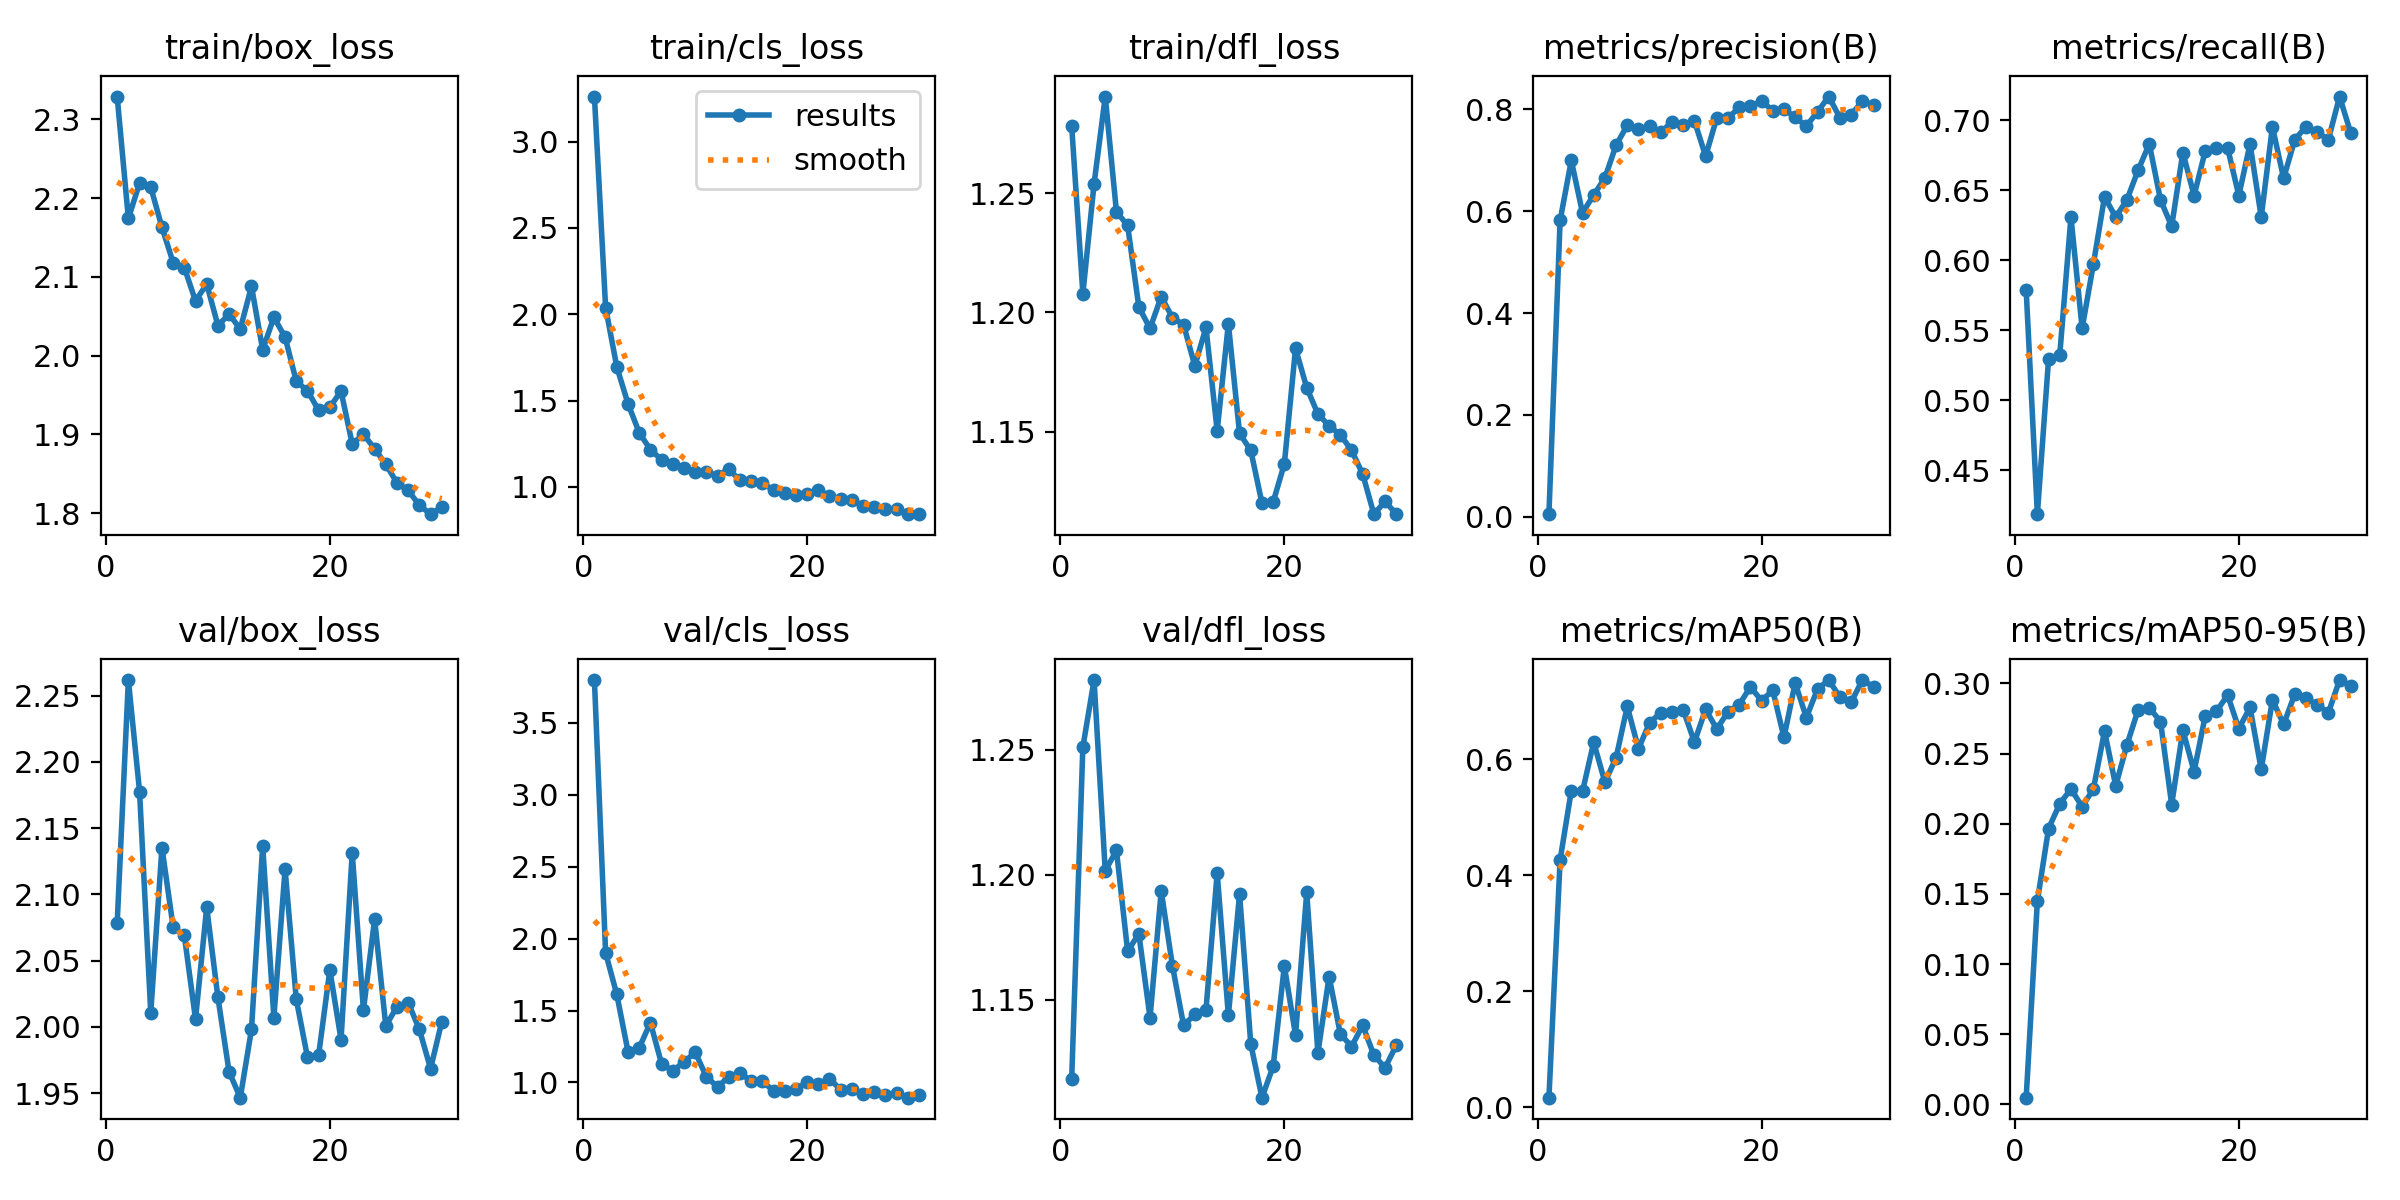



🔍 Running Inference on Unseen Validation Images...
➡️ Image 1: /content/yolo_dataset/valid/images/1-3-46-670589-33-1-63717795134921976700001-5330186835300443956_png_jpg.rf.8e2f9edc9ba0d22ce427ac8121650f62.jpg
➡️ Image 2: /content/yolo_dataset/valid/images/1-3-46-670589-33-1-63735427803549054500001-5113448086432657197_png_jpg.rf.ff6f34fc55fe65c58119153cb600eaed.jpg
➡️ Image 3: /content/yolo_dataset/valid/images/1-3-46-670589-33-1-63743022346777470600001-4648678879502469336_png_jpg.rf.68e50472c8880d492b9e3ca3f7914c9a.jpg


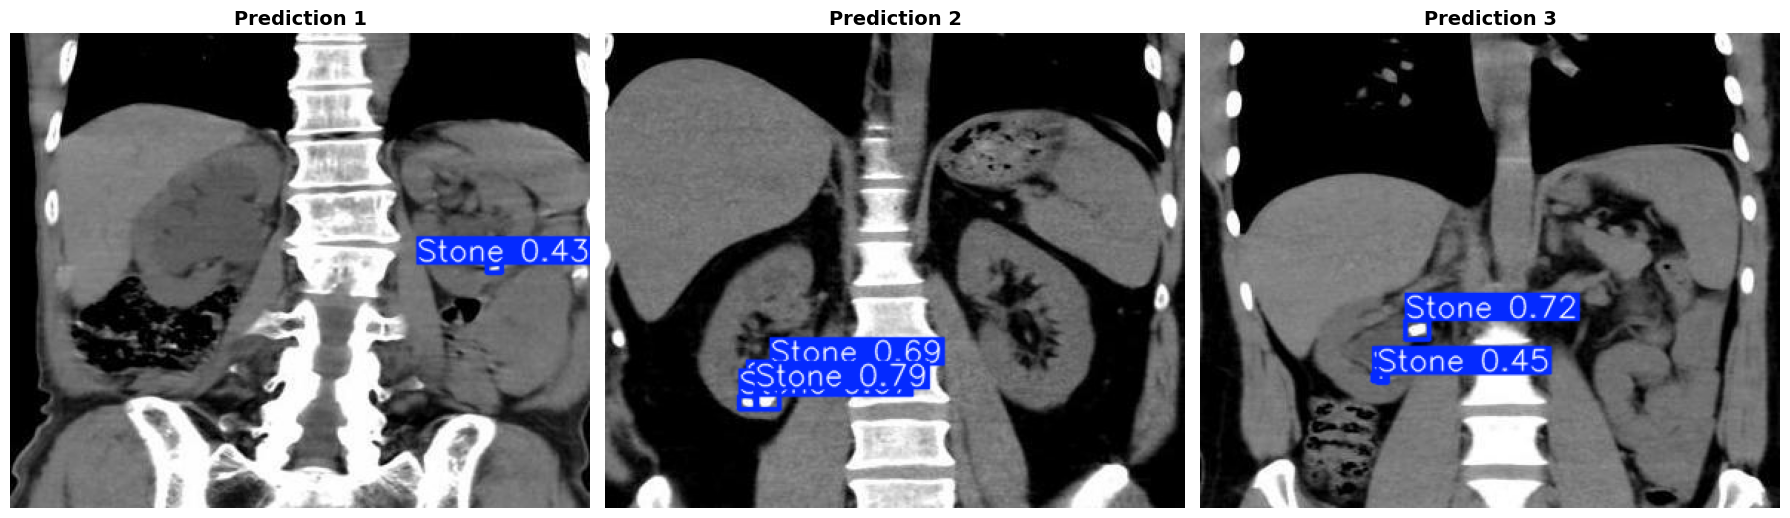


✅ Step 7C Complete: YOLO working perfectly!


In [ ]:
# ==========================================
# STEP 7C: INFERENCE & METRICS (FINAL)
# ==========================================
import os
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display

print("🔄 Loading the best trained YOLO model...")

# ✅ Correct model path
model_path = '/content/runs/detect/FYP_YOLO/kidney_stone_model/weights/best.pt'
best_yolo = YOLO(model_path)

print("✅ Model loaded successfully!")

# ─── 1. DISPLAY TRAINING METRICS ───
results_path = '/content/runs/detect/FYP_YOLO/kidney_stone_model/results.png'

if os.path.exists(results_path):
    print("\n" + "="*60)
    print("📈 FINAL TRAINING METRICS (Loss, mAP, Precision, Recall)")
    print("="*60)
    display(Image(filename=results_path, width=1000))
    print("\n")
else:
    print("⚠️ results.png not found (training still OK)")

# ─── 2. RUN INFERENCE ON VALIDATION IMAGES ───
print("🔍 Running Inference on Unseen Validation Images...")

valid_img_dir = '/content/yolo_dataset/valid/images'
test_images = glob.glob(f"{valid_img_dir}/*.jpg")[:3]

# fallback if needed
if not test_images:
    test_images = glob.glob("/content/yolo_dataset/**/*.jpg", recursive=True)[:3]

if test_images:
    fig, axes = plt.subplots(1, len(test_images), figsize=(18, 6))

    if len(test_images) == 1:
        axes = [axes]

    for i, img_path in enumerate(test_images):
        print(f"➡️ Image {i+1}: {img_path}")

        # ✅ FIXED verbose=True/False
        res = best_yolo.predict(
            source=img_path,
            conf=0.25,
            save=False,
            verbose=False
        )

        # Draw predictions
        annotated_img = res[0].plot()
        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(annotated_img)
        axes[i].axis('off')
        axes[i].set_title(f"Prediction {i+1}", fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

    print("\n✅ Step 7C Complete: YOLO working perfectly!")
else:
    print("❌ No images found! Check dataset path.")

⚙️ FINAL AI PIPELINE INITIALIZATION
🔄 Loading CNN model...
🔄 Loading YOLO model...
✅ YOLO model loaded!
✅ Models Loaded Successfully!

📸 Upload a CT scan image:


Saving 25.jpg to 25.jpg

🔍 ANALYZING: 25.jpg
🩺 CNN Prediction   : Stone
📊 Confidence      : 98.63%
   • Normal: 1.37%
   • Stone : 98.63%
------------------------------------------------------------
⚠️ Stone probability high → Running YOLO detection...


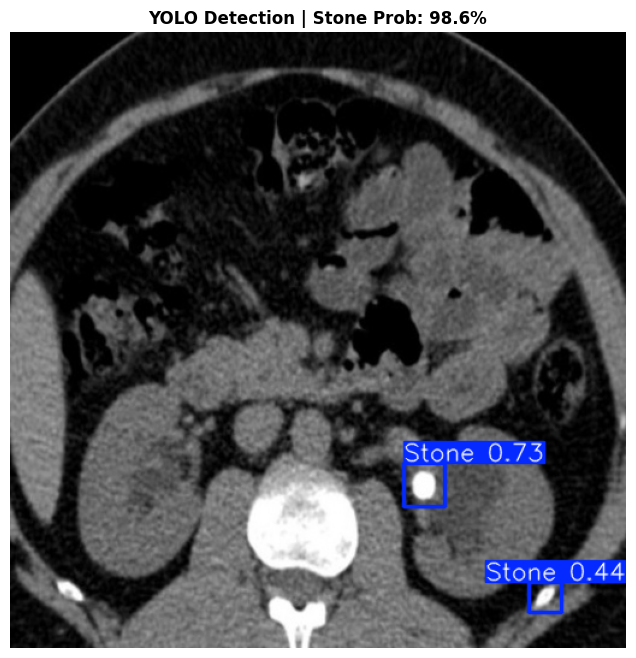

In [ ]:
# ==========================================
# STEP 10: FINAL CNN + YOLO PIPELINE (FIXED)
# ==========================================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO
from google.colab import files

print("="*60)
print("⚙️ FINAL AI PIPELINE INITIALIZATION")
print("="*60)

# ─── 1. LOAD CNN MODEL ───
print("🔄 Loading CNN model...")
cnn_model = load_model('/content/fyp_kidney_stone_binary_model.keras')

# ─── 2. LOAD YOLO MODEL ───
print("🔄 Loading YOLO model...")

yolo_path = '/content/runs/detect/FYP_YOLO/kidney_stone_model/weights/best.pt'

if not os.path.exists(yolo_path):
    raise FileNotFoundError("❌ YOLO best.pt NOT FOUND!")

yolo_model = YOLO(yolo_path)
print("✅ YOLO model loaded!")

# ─── 3. CONFIG ───
class_labels = ['Normal', 'Stone']  # ✅ FIXED (binary)
IMG_HEIGHT, IMG_WIDTH = 224, 224

print("✅ Models Loaded Successfully!\n")

# ─── 4. UPLOAD IMAGE ───
print("📸 Upload a CT scan image:")
uploaded = files.upload()

# ─── 5. PROCESS IMAGE ───
for filename in uploaded.keys():

    print("\n" + "="*60)
    print(f"🔍 ANALYZING: {filename}")
    print("="*60)

    # ─── CNN PREPROCESS ───
    img_cnn = image.load_img(filename, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img_cnn) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # ─── CNN PREDICTION ───
    preds = cnn_model.predict(img_array, verbose=0)[0]

    stone_prob = preds[0]  # if sigmoid output
    normal_prob = 1 - stone_prob

    if stone_prob >= 0.5:
        pred_class = "Stone"
        confidence = stone_prob * 100
    else:
        pred_class = "Normal"
        confidence = normal_prob * 100

    # ─── PRINT RESULTS ───
    print(f"🩺 CNN Prediction   : {pred_class}")
    print(f"📊 Confidence      : {confidence:.2f}%")
    print(f"   • Normal: {normal_prob*100:.2f}%")
    print(f"   • Stone : {stone_prob*100:.2f}%")
    print("-"*60)

    # ─── SMART YOLO TRIGGER ───
    if stone_prob > 0.30:
        print("⚠️ Stone probability high → Running YOLO detection...")

        results = yolo_model.predict(
            source=filename,
            conf=0.25,
            save=False,
            verbose=False
        )

        output_img = results[0].plot()
        output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

        title = f"YOLO Detection | Stone Prob: {stone_prob*100:.1f}%"

    else:
        print("✅ No strong stone signal → Skipping YOLO")

        output_img = cv2.imread(filename)
        output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

        title = f"CNN Result: {pred_class} ({confidence:.1f}%)"

    # ─── DISPLAY RESULT ───
    plt.figure(figsize=(8,8))
    plt.imshow(output_img)
    plt.axis('off')
    plt.title(title, fontweight='bold')
    plt.show()

In [ ]:
# ==========================================
# PHASE 2: TABULAR ML PIPELINE (LAB DATA)
# ==========================================
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ─── OPTIONAL: GENERATE MOCK DATA FOR TESTING ───
# If you don't have the real CSV yet, this creates a realistic dummy dataset to test the pipeline
if not os.path.exists('kidney_lab_data.csv'):
    print("⚠️ 'kidney_lab_data.csv' not found. Generating mock dataset for demonstration...")
    np.random.seed(42)
    n_samples = 500
    mock_data = pd.DataFrame({
        'Age': np.random.randint(20, 80, n_samples),
        'Creatinine': np.random.uniform(0.5, 3.0, n_samples),
        'Calcium': np.random.uniform(8.0, 11.5, n_samples),
        'Uric_Acid': np.random.uniform(3.0, 9.0, n_samples),
        'pH': np.random.uniform(4.5, 8.0, n_samples),
        'Stone': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]) # 30% have stones
    })
    # Add some realistic medical correlations for the models to learn
    mock_data.loc[mock_data['Stone'] == 1, 'Calcium'] += 1.5
    mock_data.loc[mock_data['Stone'] == 1, 'Uric_Acid'] += 2.0
    mock_data.to_csv('kidney_lab_data.csv', index=False)

# ==========================================
# 1. LOAD & PREPROCESS
# ==========================================
def load_and_preprocess_data(csv_path):
    print(f"🔄 Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    # 1. Handle Missing Values (Replace NaN with column median)
    imputer = SimpleImputer(strategy='median')
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

    # 2. Separate Features (X) and Target (y)
    X = df_imputed.drop('Stone', axis=1)
    y = df_imputed['Stone']

    # 3. Train-Test Split (80% Train, 20% Test)
    # stratify=y ensures the 80/20 split has the same ratio of stones vs normal
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 4. Feature Scaling (StandardScaler) - Critical for SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save Scaler for later API use
    joblib.dump(scaler, 'scaler.pkl')
    print("✅ Preprocessing complete. Scaler saved to 'scaler.pkl'.")

    return X_train_scaled, X_test_scaled, y_train, y_test, X.columns

# ==========================================
# 2. TRAIN & EVALUATE MODELS
# ==========================================
def evaluate_model(y_true, y_pred, model_name):
    """Calculates FYP metrics and prints them neatly"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n📊 {model_name} Metrics:")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall   : {rec:.4f}")
    print(f"   F1-Score : {f1:.4f}")
    print(f"   Confusion Matrix:\n{cm}")

    # For imbalanced medical data, F1-Score is the best metric to judge by
    return f1

def train_models(X_train, y_train, X_test, y_test):
    print("\n⚙️ Training Models...")

    # Model 1: Support Vector Machine (SVM)
    # probability=True is required so we can get % confidence later
    svm_model = SVC(kernel='rbf', probability=True, random_state=42)
    svm_model.fit(X_train, y_train)
    svm_preds = svm_model.predict(X_test)
    svm_f1 = evaluate_model(y_test, svm_preds, "Support Vector Machine (SVM)")

    # Model 2: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)
    rf_f1 = evaluate_model(y_test, rf_preds, "Random Forest")

    # Auto-Select Best Model based on F1-Score
    print("\n" + "="*40)
    print("🏆 MODEL COMPARISON & SELECTION")
    print("="*40)

    if rf_f1 > svm_f1:
        print(f"✅ Random Forest won with an F1-Score of {rf_f1:.4f}")
        best_model = rf_model
    else:
        print(f"✅ SVM won with an F1-Score of {svm_f1:.4f}")
        best_model = svm_model

    # Save the winning model
    joblib.dump(best_model, 'kidney_model.pkl')
    print("💾 Best model saved to 'kidney_model.pkl'.")

    return best_model

# ==========================================
# 3. TEST PIPELINE (INFERENCE)
# ==========================================
def test_pipeline(feature_names):
    print("\n🧪 Running a sample prediction using saved files...")

    # Load the saved files (This is exactly what your API will do!)
    loaded_scaler = joblib.load('scaler.pkl')
    loaded_model = joblib.load('kidney_model.pkl')

    # Dummy patient lab report: Age=45, Creatinine=1.2, Calcium=10.5, Uric_Acid=7.8, pH=5.5
    new_patient = np.array([[45, 1.2, 10.5, 7.8, 5.5]])

    # 1. Scale input using the saved scaler
    scaled_input = loaded_scaler.transform(new_patient)

    # 2. Predict
    prediction = loaded_model.predict(scaled_input)[0]
    probability = loaded_model.predict_proba(scaled_input)[0][1] # Get probability for class 1 (Stone)

    result = "STONE DETECTED 🔴" if prediction == 1 else "NORMAL 🟢"

    print(f"🩺 Patient Lab Data: {dict(zip(feature_names, new_patient[0]))}")
    print(f"📋 Diagnosis: {result}")
    print(f"📊 Confidence: {max(probability, 1-probability)*100:.2f}%")


# --- RUN THE ENTIRE PIPELINE ---
X_train, X_test, y_train, y_test, features = load_and_preprocess_data('kidney_lab_data.csv')
best_model = train_models(X_train, y_train, X_test, y_test)
test_pipeline(features)


⚠️ 'kidney_lab_data.csv' not found. Generating mock dataset for demonstration...
🔄 Loading data from kidney_lab_data.csv...
✅ Preprocessing complete. Scaler saved to 'scaler.pkl'.

⚙️ Training Models...

📊 Support Vector Machine (SVM) Metrics:
   Accuracy : 0.8600
   Precision: 0.8500
   Recall   : 0.6071
   F1-Score : 0.7083
   Confusion Matrix:
[[69  3]
 [11 17]]

📊 Random Forest Metrics:
   Accuracy : 0.9500
   Precision: 0.8966
   Recall   : 0.9286
   F1-Score : 0.9123
   Confusion Matrix:
[[69  3]
 [ 2 26]]

🏆 MODEL COMPARISON & SELECTION
✅ Random Forest won with an F1-Score of 0.9123
💾 Best model saved to 'kidney_model.pkl'.

🧪 Running a sample prediction using saved files...
🩺 Patient Lab Data: {'Age': np.float64(45.0), 'Creatinine': np.float64(1.2), 'Calcium': np.float64(10.5), 'Uric_Acid': np.float64(7.8), 'pH': np.float64(5.5)}
📋 Diagnosis: NORMAL 🟢
📊 Confidence: 64.00%


In [ ]:
import shutil
import os
from google.colab import drive

# 1. Make sure Drive is mounted
drive.mount('/content/drive', force_remount=True)

# 2. Create a backup folder in your Drive
drive_backup_folder = '/content/drive/MyDrive/FYP_Models_Backup'
os.makedirs(drive_backup_folder, exist_ok=True)

print(f"📁 Saving models to: {drive_backup_folder}\n")

# 3. List of all the models we generated today
files_to_backup = [
    '/content/fyp_kidney_stone_binary_model.h5',
    '/content/runs/detect/FYP_YOLO/kidney_stone_model/weights/best.pt',
    '/content/kidney_model.pkl',
    '/content/scaler.pkl'
]

# 4. Copy them over safely
for file_path in files_to_backup:
    if os.path.exists(file_path):
        file_name = os.path.basename(file_path)

        # Rename the YOLO model so you know what it is
        if file_name == 'best.pt':
            file_name = 'yolov8_kidneystone_best.pt'

        destination = os.path.join(drive_backup_folder, file_name)
        shutil.copy(file_path, destination)
        print(f"✅ Successfully backed up: {file_name}")
    else:
        print(f"❌ Could not find: {file_path} (Did the training finish?)")

print("\n🎉 Backup Complete! You can safely close Colab knowing your models are saved forever.")


Mounted at /content/drive
📁 Saving models to: /content/drive/MyDrive/FYP_Models_Backup

❌ Could not find: /content/fyp_kidney_stone_binary_model.h5 (Did the training finish?)
✅ Successfully backed up: yolov8_kidneystone_best.pt
✅ Successfully backed up: kidney_model.pkl
✅ Successfully backed up: scaler.pkl

🎉 Backup Complete! You can safely close Colab knowing your models are saved forever.


In [ ]:
import os
print(os.listdir('/content/'))


['.config', 'fyp_kidney_stone_binary_model.keras', 'kidney_lab_data.csv', 'yolov8n.pt', 'kidney_model.pkl', 'dataset.yaml', 'runs', 'yolo26n.pt', '25.jpg', 'yolo_dataset', 'drive', 'scaler.pkl', 'cnn_dataset_clean', 'sample_data']


In [ ]:
import shutil
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
drive_backup_folder = '/content/drive/MyDrive/FYP_Models_Backup'

# ✅ UPDATED to use .keras
files_to_backup = [
    '/content/fyp_kidney_stone_binary_model.keras',
    '/content/runs/detect/FYP_YOLO/kidney_stone_model/weights/best.pt',
    '/content/kidney_model.pkl',
    '/content/scaler.pkl'
]

for file_path in files_to_backup:
    if os.path.exists(file_path):
        file_name = os.path.basename(file_path)
        if file_name == 'best.pt':
            file_name = 'yolov8_kidneystone_best.pt'

        destination = os.path.join(drive_backup_folder, file_name)
        shutil.copy(file_path, destination)
        print(f"✅ Successfully backed up: {file_name}")
    else:
        print(f"❌ Still could not find: {file_path}")


Mounted at /content/drive
✅ Successfully backed up: fyp_kidney_stone_binary_model.keras
✅ Successfully backed up: yolov8_kidneystone_best.pt
✅ Successfully backed up: kidney_model.pkl
✅ Successfully backed up: scaler.pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# FINAL MASTER API (Runs in Colab Background)
# ==========================================
import os
import cv2
import uuid
import logging
import threading
import numpy as np
import pandas as pd
import joblib
from flask import Flask, request, jsonify
from werkzeug.utils import secure_filename
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO

app = Flask(__name__, static_folder='static')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

UPLOAD_FOLDER = 'uploads'
OUTPUT_FOLDER = 'static/outputs'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
ALLOWED_EXTENSIONS = {'png', 'jpg', 'jpeg'}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in ALLOWED_EXTENSIONS

# ✅ UPDATED: Permanent Google Drive Paths
CNN_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/fyp_kidney_stone_binary_model.keras'
YOLO_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/yolov8_kidneystone_best.pt'
ML_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/kidney_model.pkl'
SCALER_PATH = '/content/drive/MyDrive/FYP_Models_Backup/scaler.pkl'

print("🔄 Loading models from Drive...")
cnn_model = load_model(CNN_MODEL_PATH)
yolo_model = YOLO(YOLO_MODEL_PATH)
rf_model = joblib.load(ML_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
print("✅ All Models Loaded Successfully!")

# --- HELPERS ---
def preprocess_image_for_cnn(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def cnn_predict(img_path):
    return float(cnn_model.predict(preprocess_image_for_cnn(img_path), verbose=0)[0][0])

def yolo_detect(img_path, output_filename):
    results = yolo_model.predict(source=img_path, conf=0.25, save=False, verbose=False)
    boxes = results[0].boxes
    detections_count = len(boxes) if boxes is not None and len(boxes) > 0 else 0
    cv2.imwrite(os.path.join(OUTPUT_FOLDER, output_filename), results[0].plot())
    return detections_count, os.path.join(OUTPUT_FOLDER, output_filename)

def lab_predict(data_dict):
    features = ['Age', 'Creatinine', 'Calcium', 'Uric_Acid', 'pH']
    values = [float(data_dict[f]) for f in features]
    df_input = pd.DataFrame([values], columns=features)
    scaled_input = scaler.transform(df_input)
    return int(rf_model.predict(scaled_input)[0]), float(rf_model.predict_proba(scaled_input)[0][1])

# --- ENDPOINTS ---
@app.route('/', methods=['GET'])
def home():
    return jsonify({"status": "online", "message": "API is running!"})

@app.route('/predict', methods=['POST'])
def predict_image():
    file = request.files.get('image')
    if not file or not allowed_file(file.filename):
        return jsonify({"error": "Invalid or missing image"}), 400

    unique_filename = f"{uuid.uuid4().hex}_{secure_filename(file.filename)}"
    input_path = os.path.join(UPLOAD_FOLDER, unique_filename)
    file.save(input_path)

    try:
        stone_prob = cnn_predict(input_path)
        yolo_triggered = stone_prob > 0.30

        detections_count = 0
        annotated_image_url = None

        if yolo_triggered:
            detections_count, saved_path = yolo_detect(input_path, f"annotated_{unique_filename}")
            annotated_image_url = f"{request.host_url}{saved_path}"

        res = {
            "predicted_class": "Stone" if yolo_triggered else "Normal",
            "confidence": round(max(stone_prob, 1.0 - stone_prob) * 100, 2),
            "stone_probability": round(stone_prob, 4),
            "yolo_triggered": yolo_triggered,
            "detections_count": detections_count
        }
        if yolo_triggered: res["annotated_image"] = annotated_image_url
        return jsonify(res), 200
    finally:
        if os.path.exists(input_path): os.remove(input_path)

@app.route('/predict-lab', methods=['POST'])
def predict_lab_endpoint():
    data = request.get_json()
    try:
        class_pred, stone_prob = lab_predict(data)
        return jsonify({
            "predicted_class": "Stone" if class_pred == 1 else "Normal",
            "confidence": round(max(stone_prob, 1.0 - stone_prob) * 100, 2),
            "stone_probability": round(stone_prob, 4)
        }), 200
    except Exception as e:
        return jsonify({"error": str(e)}), 400

# ✅ START SERVER IN BACKGROUND THREAD
def run_app():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

server_thread = threading.Thread(target=run_app)
server_thread.start()

print("\n🚀 FLASK SERVER IS RUNNING IN THE BACKGROUND AT http://127.0.0.1:5000")


🔄 Loading models from Drive...
✅ All Models Loaded Successfully!

🚀 FLASK SERVER IS RUNNING IN THE BACKGROUND AT http://127.0.0.1:5000


In [ ]:
import requests

print("🧪 TESTING ENDPOINT 1: Health Check")
res = requests.get('http://127.0.0.1:5000/')
print(res.json())

print("\n🧪 TESTING ENDPOINT 2: Lab Data Machine Learning")
# Simulating JSON data from a patient
lab_data = {
  "Age": 45,
  "Creatinine": 1.2,
  "Calcium": 10.5,
  "Uric_Acid": 7.8,
  "pH": 5.5
}
res_lab = requests.post('http://127.0.0.1:5000/predict-lab', json=lab_data)
print(res_lab.json())

print("\n✅ API IS FULLY FUNCTIONAL!")


INFO:werkzeug:127.0.0.1 - - [26/Apr/2026 23:18:14] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [26/Apr/2026 23:18:14] "POST /predict-lab HTTP/1.1" 200 -


🧪 TESTING ENDPOINT 1: Health Check
{'message': 'API is running!', 'status': 'online'}

🧪 TESTING ENDPOINT 2: Lab Data Machine Learning
{'confidence': 64.0, 'predicted_class': 'Normal', 'stone_probability': 0.36}

✅ API IS FULLY FUNCTIONAL!


In [ ]:
# ==========================================
# FINAL MASTER API (Runs in Colab Background)
# ==========================================
import os
import cv2
import uuid
import logging
import threading
import numpy as np
import pandas as pd
import joblib
from flask import Flask, request, jsonify
from werkzeug.utils import secure_filename
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO

app = Flask(__name__, static_folder='static')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

UPLOAD_FOLDER = 'uploads'
OUTPUT_FOLDER = 'static/outputs'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
ALLOWED_EXTENSIONS = {'png', 'jpg', 'jpeg'}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in ALLOWED_EXTENSIONS

# ✅ UPDATED: Permanent Google Drive Paths
CNN_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/fyp_kidney_stone_binary_model.keras'
YOLO_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/yolov8_kidneystone_best.pt'
ML_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/kidney_model.pkl'
SCALER_PATH = '/content/drive/MyDrive/FYP_Models_Backup/scaler.pkl'

print("🔄 Loading models from Drive...")
cnn_model = load_model(CNN_MODEL_PATH)
yolo_model = YOLO(YOLO_MODEL_PATH)
rf_model = joblib.load(ML_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
print("✅ All Models Loaded Successfully!")

# --- HELPERS ---
def preprocess_image_for_cnn(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def cnn_predict(img_path):
    return float(cnn_model.predict(preprocess_image_for_cnn(img_path), verbose=0)[0][0])

def yolo_detect(img_path, output_filename):
    results = yolo_model.predict(source=img_path, conf=0.25, save=False, verbose=False)
    boxes = results[0].boxes
    detections_count = len(boxes) if boxes is not None and len(boxes) > 0 else 0
    cv2.imwrite(os.path.join(OUTPUT_FOLDER, output_filename), results[0].plot())
    return detections_count, os.path.join(OUTPUT_FOLDER, output_filename)

def lab_predict(data_dict):
    features = ['Age', 'Creatinine', 'Calcium', 'Uric_Acid', 'pH']
    values = [float(data_dict[f]) for f in features]
    df_input = pd.DataFrame([values], columns=features)
    scaled_input = scaler.transform(df_input)
    return int(rf_model.predict(scaled_input)[0]), float(rf_model.predict_proba(scaled_input)[0][1])

# --- ENDPOINTS ---
@app.route('/', methods=['GET'])
def home():
    return jsonify({"status": "online", "message": "API is running!"})

@app.route('/predict', methods=['POST'])
def predict_image():
    file = request.files.get('image')
    if not file or not allowed_file(file.filename):
        return jsonify({"error": "Invalid or missing image"}), 400

    unique_filename = f"{uuid.uuid4().hex}_{secure_filename(file.filename)}"
    input_path = os.path.join(UPLOAD_FOLDER, unique_filename)
    file.save(input_path)

    try:
        stone_prob = cnn_predict(input_path)
        yolo_triggered = stone_prob > 0.30

        detections_count = 0
        annotated_image_url = None

        if yolo_triggered:
            detections_count, saved_path = yolo_detect(input_path, f"annotated_{unique_filename}")
            annotated_image_url = f"{request.host_url}{saved_path}"

        res = {
            "predicted_class": "Stone" if yolo_triggered else "Normal",
            "confidence": round(max(stone_prob, 1.0 - stone_prob) * 100, 2),
            "stone_probability": round(stone_prob, 4),
            "yolo_triggered": yolo_triggered,
            "detections_count": detections_count
        }
        if yolo_triggered: res["annotated_image"] = annotated_image_url
        return jsonify(res), 200
    finally:
        if os.path.exists(input_path): os.remove(input_path)

@app.route('/predict-lab', methods=['POST'])
def predict_lab_endpoint():
    data = request.get_json()
    try:
        class_pred, stone_prob = lab_predict(data)
        return jsonify({
            "predicted_class": "Stone" if class_pred == 1 else "Normal",
            "confidence": round(max(stone_prob, 1.0 - stone_prob) * 100, 2),
            "stone_probability": round(stone_prob, 4)
        }), 200
    except Exception as e:
        return jsonify({"error": str(e)}), 400

# ✅ START SERVER IN BACKGROUND THREAD
def run_app():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

server_thread = threading.Thread(target=run_app)
server_thread.start()

print("\n🚀 FLASK SERVER IS RUNNING IN THE BACKGROUND AT http://127.0.0.1:5000")


🔄 Loading models from Drive...
✅ All Models Loaded Successfully!
 * Serving Flask app '__main__'

🚀 FLASK SERVER IS RUNNING IN THE BACKGROUND AT http://127.0.0.1:5000
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [ ]:
import requests

res = requests.get("http://127.0.0.1:5000/")
print(res.json())

INFO:werkzeug:127.0.0.1 - - [26/Apr/2026 23:28:15] "GET / HTTP/1.1" 200 -


{'message': 'API is running!', 'status': 'online'}


In [ ]:
import requests

lab_data = {
  "Age": 45,
  "Creatinine": 1.2,
  "Calcium": 10.5,
  "Uric_Acid": 7.8,
  "pH": 5.5
}

res = requests.post("http://127.0.0.1:5000/predict-lab", json=lab_data)
print(res.json())

INFO:werkzeug:127.0.0.1 - - [26/Apr/2026 23:30:23] "POST /predict-lab HTTP/1.1" 200 -


{'confidence': 64.0, 'predicted_class': 'Normal', 'stone_probability': 0.36}


In [ ]:
from google.colab import files
files.upload()

Saving 25.jpg to 25 (1).jpg


{'25 (1).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02\x01\x01\x01\x02\x02\x02\x02\x02\x04\x03\x02\x02\x02\x02\x05\x04\x04\x03\x04\x06\x05\x06\x06\x06\x05\x06\x06\x06\x07\t\x08\x06\x07\t\x07\x06\x06\x08\x0b\x08\t\n\n\n\n\n\x06\x08\x0b\x0c\x0b\n\x0c\t\n\n\n\xff\xdb\x00C\x01\x02\x02\x02\x02\x02\x02\x05\x03\x03\x05\n\x07\x06\x07\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\xff\xc0\x00\x11\x08\x02\x00\x02\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x

In [ ]:
import requests

image_path = '25 (1).jpg'  # ⚠️ exact name from upload

url = 'http://127.0.0.1:5000/predict'

files = {'image': open(image_path, 'rb')}

response = requests.post(url, files=files)

print(response.json())

INFO:werkzeug:127.0.0.1 - - [26/Apr/2026 23:36:31] "POST /predict HTTP/1.1" 200 -


{'annotated_image': 'http://127.0.0.1:5000/static/outputs/annotated_6944386a76be43a786ce29b21cb91094_25_1.jpg', 'confidence': 98.63, 'detections_count': 2, 'predicted_class': 'Stone', 'stone_probability': 0.9863, 'yolo_triggered': True}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q ultralytics

In [ ]:
!fuser -k 5000/tcp


In [ ]:
# =after restart=========================================
# START MASTER API FROM GOOGLE DRIVE
# ==========================================
from google.colab import drive
import os
import cv2
import uuid
import logging
import threading
import numpy as np
import pandas as pd
import joblib
from flask import Flask, request, jsonify
from werkzeug.utils import secure_filename
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO

# 1. MOUNT DRIVE
drive.mount('/content/drive', force_remount=True)

# 2. SETUP FLASK
app = Flask(__name__, static_folder='static')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
os.makedirs('uploads', exist_ok=True)
os.makedirs('static/outputs', exist_ok=True)
ALLOWED_EXTENSIONS = {'png', 'jpg', 'jpeg'}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in ALLOWED_EXTENSIONS

# 3. LOAD MODELS FROM DRIVE
CNN_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/fyp_kidney_stone_binary_model.keras'
YOLO_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/yolov8_kidneystone_best.pt'
ML_MODEL_PATH = '/content/drive/MyDrive/FYP_Models_Backup/kidney_model.pkl'
SCALER_PATH = '/content/drive/MyDrive/FYP_Models_Backup/scaler.pkl'

print("🔄 Loading models directly from Google Drive...")
try:
    cnn_model = load_model(CNN_MODEL_PATH)
    yolo_model = YOLO(YOLO_MODEL_PATH)
    rf_model = joblib.load(ML_MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    print("✅ All 4 Models Loaded Successfully!")
except Exception as e:
    raise RuntimeError(f"❌ Model loading failed: {e}")

# --- HELPERS ---
def preprocess_image_for_cnn(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def cnn_predict(img_path):
    return float(cnn_model.predict(preprocess_image_for_cnn(img_path), verbose=0)[0][0])

def yolo_detect(img_path, output_filename):
    results = yolo_model.predict(source=img_path, conf=0.25, save=False, verbose=False)
    boxes = results[0].boxes
    detections_count = len(boxes) if boxes is not None and len(boxes) > 0 else 0
    cv2.imwrite(os.path.join('static/outputs', output_filename), results[0].plot())
    return detections_count, os.path.join('static/outputs', output_filename)

def lab_predict(data_dict):
    features = ['Age', 'Creatinine', 'Calcium', 'Uric_Acid', 'pH']
    values = [float(data_dict[f]) for f in features]
    df_input = pd.DataFrame([values], columns=features)
    scaled_input = scaler.transform(df_input)
    return int(rf_model.predict(scaled_input)[0]), float(rf_model.predict_proba(scaled_input)[0][1])

# --- ENDPOINTS ---
@app.route('/', methods=['GET'])
def home():
    return jsonify({"status": "online", "message": "API is running!"})

@app.route('/predict', methods=['POST'])
def predict_image():
    file = request.files.get('image')
    if not file or not allowed_file(file.filename):
        return jsonify({"error": "Invalid or missing image"}), 400

    unique_filename = f"{uuid.uuid4().hex}_{secure_filename(file.filename)}"
    input_path = os.path.join('uploads', unique_filename)
    file.save(input_path)

    try:
        stone_prob = cnn_predict(input_path)
        yolo_triggered = stone_prob > 0.30

        detections_count = 0
        annotated_image_url = None

        if yolo_triggered:
            detections_count, saved_path = yolo_detect(input_path, f"annotated_{unique_filename}")
            annotated_image_url = f"{request.host_url}{saved_path}"

        res = {
            "predicted_class": "Stone" if yolo_triggered else "Normal",
            "confidence": round(max(stone_prob, 1.0 - stone_prob) * 100, 2),
            "stone_probability": round(stone_prob, 4),
            "yolo_triggered": yolo_triggered,
            "detections_count": detections_count
        }
        if yolo_triggered: res["annotated_image"] = annotated_image_url
        return jsonify(res), 200
    finally:
        if os.path.exists(input_path): os.remove(input_path)

@app.route('/predict-lab', methods=['POST'])
def predict_lab_endpoint():
    data = request.get_json()
    if not data: return jsonify({"error": "Missing JSON payload"}), 400
    try:
        class_pred, stone_prob = lab_predict(data)
        res = {
            "predicted_class": "Stone" if class_pred == 1 else "Normal",
            "confidence": round(max(stone_prob, 1.0 - stone_prob) * 100, 2),
            "stone_probability": round(stone_prob, 4)
        }
        return jsonify(res), 200
    except Exception as e:
        return jsonify({"error": str(e)}), 400

# 4. START SERVER IN BACKGROUND THREAD
def run_app():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

server_thread = threading.Thread(target=run_app)
server_thread.start()

print("\n🚀 FLASK SERVER IS RUNNING IN THE BACKGROUND AT http://127.0.0.1:5000")


Mounted at /content/drive
🔄 Loading models directly from Google Drive...
✅ All 4 Models Loaded Successfully!

🚀 FLASK SERVER IS RUNNING IN THE BACKGROUND AT http://127.0.0.1:5000
 * Serving Flask app '__main__'
 * Debug mode: off


In [ ]:
import requests

print("🧪 TESTING ENDPOINT 1: Health Check")
try:
    res = requests.get('http://127.0.0.1:5000/')
    print(res.json())
except Exception as e:
    print("❌ Failed to reach server. Make sure Cell 1 is running!")

print("\n🧪 TESTING ENDPOINT 2: Lab Data Machine Learning")
# Simulating JSON data from a patient
lab_data = {
  "Age": 45,
  "Creatinine": 1.2,
  "Calcium": 10.5,
  "Uric_Acid": 7.8,
  "pH": 5.5
}
try:
    res_lab = requests.post('http://127.0.0.1:5000/predict-lab', json=lab_data)
    print(res_lab.json())
    print("\n✅ API IS FULLY FUNCTIONAL!")
except Exception as e:
    print("❌ Failed to reach lab endpoint.")


INFO:werkzeug:127.0.0.1 - - [27/Apr/2026 20:23:58] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Apr/2026 20:23:58] "POST /predict-lab HTTP/1.1" 200 -


🧪 TESTING ENDPOINT 1: Health Check
{'message': 'API is running!', 'status': 'online'}

🧪 TESTING ENDPOINT 2: Lab Data Machine Learning
{'confidence': 64.0, 'predicted_class': 'Normal', 'stone_probability': 0.36}

✅ API IS FULLY FUNCTIONAL!


In [ ]:
!pip install -q pyngrok

In [ ]:
from pyngrok import ngrok

# set token
ngrok.set_auth_token("3CxG5bnUfsWROs67IN65341XbP8_4MSPBiM6ie17qpwueQtdt")

# connect to existing server (already running from Cell 2)
public_url = ngrok.connect(5000)

print("🌍 PUBLIC URL:", public_url)

🌍 PUBLIC URL: NgrokTunnel: "https://strewn-hazelnut-spiritual.ngrok-free.dev" -> "http://localhost:5000"
